#Libraries

In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from scipy.stats import norm
from scipy.optimize import brentq
from mpl_toolkits.mplot3d import Axes3D
from operator import index
from scipy.optimize import least_squares

#Function definition

In [86]:
def get_options(ticker, start_date, finish_date,valuation_date):
  start_date=pd.to_datetime(start_date,format="%m/%d/%Y")
  finish_date=pd.to_datetime(finish_date,format="%m/%d/%Y")
  #trade_date=pd.to_datetime(trade_date,format="%m/%d/%Y")
  valuation_date=pd.to_datetime(valuation_date)
  Ticker=yf.Ticker(ticker)
  exp_date=pd.to_datetime(Ticker.options)
  valid_expires=exp_date[(exp_date>=start_date)&(exp_date<=finish_date)]
  options_data=[]

  Underlying=Ticker.fast_info['last_price']
  if Underlying is None:
    Underlying=Ticker.history(period="1d").iloc[-1]

  for expiry in valid_expires:
    chain=Ticker.option_chain(expiry.strftime("%Y-%m-%d"))
    dte=max(1/365,(expiry-valuation_date).days/365)
    calls=chain.calls.assign(expiry=expiry,type="call",Spot=Underlying,T=dte)
    puts=chain.puts.assign(expiry=expiry,type="put",Spot=Underlying,T=dte)
    options_data.append(pd.concat([calls,puts],ignore_index=True))

  df = pd.concat(options_data, ignore_index=True)
  df["valuation_date"] = valuation_date
  return df

In [87]:
def d1_d2(S,K,r,q,sigma,T):
  d1=(np.log(S/K)+(r-q+sigma**2/2)*T)/(sigma*np.sqrt(T))
  d2=d1-sigma*np.sqrt(T)
  return d1,d2

def vega(S,K,r,q,sigma,T):
  #return S*np.sqrt(T)*norm.pdf(d1_d1(S,K,r,sigma,T)[0])
  return S*np.exp(-q*T)*np.sqrt(T)*norm.pdf(d1_d2(S,K,r,q,sigma,T)[0])

def C_bs(S,K,r,q,sigma,T):
  #return S*norm.cdf(d1_d1(S,K,r,sigma,T)[0])-K*np.exp(-r*T)*norm.cdf(d1_d1(S,K,r,sigma,T)[1])
  return S*np.exp(-q*T)*norm.cdf(d1_d2(S,K,r,q,sigma,T)[0])-K*np.exp(-r*T)*norm.cdf(d1_d2(S,K,r,q,sigma,T)[1])

def P_bs(S,K,r,q,sigma,T):
  #return K*np.exp(-r*T)*norm.cdf(-d1_d1(S,K,r,sigma,T)[1])-S*norm.cdf(-d1_d1(S,K,r,sigma,T)[0])
  return K*np.exp(-r*T)*norm.cdf(-d1_d2(S,K,r,q,sigma,T)[1])-S*np.exp(-q*T)*norm.cdf(-d1_d2(S,K,r,q,sigma,T)[0])


def iv(initial_guess,mkt_price,S,K,r,q,T,c_p,tol=1e-6,max_iter=50):
  def price_diff(sigma):
    if c_p=='call':
      return C_bs(S,K,r,q,sigma,T)-mkt_price
    else:
      return P_bs(S,K,r,q,sigma,T)-mkt_price
  lower_bound,higher_bound=1e-6,20

  try:
    if price_diff(lower_bound)*price_diff(higher_bound)>0:
      return np.nan
    return brentq(price_diff,lower_bound,higher_bound,xtol=tol,maxiter=max_iter)
  except Exception:
    return np.nan


  '''sigma=initial_guess #newton rapshon
  for i in range(max_iter):
    if c_p=='call':
      price=C_bs(S,K,r,q,sigma,T)
    else:
      price=P_bs(S,K,r,q,sigma,T)
    Vega=vega(S,K,r,q,sigma,T)

    if Vega < 1e-8:
      return np.nan
    diff=price-mkt_price
    if abs(diff)<tol:
      return sigma
    sigma = max(1e-6, sigma - diff/Vega)
  return sigma'''

def q_putcall(options):#Not used rn need to fix it because as dte decreat T makes the result explode 1/T-->0
  call_put=options.pivot_table(
      index=["expiry",'strike'],
      columns='type',
      values='mid'
  ).dropna()

  meta=options.groupby(['expiry','strike'])[['Spot','rf','T']].first()
  call_put=call_put.join(meta)

  q = -(1/call_put["T"])*np.log(
        (call_put["call"]-call_put["put"]
         +call_put.index.get_level_values("strike")
           *np.exp(-call_put["rf"]*call_put["T"]))
        /call_put["Spot"]
    )

  return q

def db_setup(options,rf,q):
  OTM_options=options.loc[options['inTheMoney']==False].copy()
  OTM_options['rf']=np.interp(OTM_options['T']*365,sofr_df['GG'],sofr_df['Rate'])
  OTM_options['mid']=(OTM_options['bid']+OTM_options['ask'])/2
  '''df=options.copy()#remove the comment once q_putcall is fixed
  df['rf']=np.interp(df['T']*365,rf['GG'],rf['Rate'])
  df['mid']=(df['bid']+df['ask'])/2
  q=q_putcall(df)
  OTM_options=df.loc[options['inTheMoney']==False].copy()'''

  OTM_options=OTM_options[
      (OTM_options['T']>0)&
      (OTM_options['mid']>0.05)&
      ((OTM_options['volume']>0)|(OTM_options['openInterest']>10))&
      (OTM_options['rf'].notna())
  ].copy()
  OTM_options['q']=q
  OTM_options['F']=OTM_options['Spot']*np.exp((OTM_options['rf']-OTM_options['q'])*OTM_options['T'])
  OTM_options['log_moneyness']=np.log(OTM_options['strike']/OTM_options['F'])
  OTM_options=OTM_options[
      (OTM_options['log_moneyness']>np.log(0.5))&
      (OTM_options['log_moneyness']<np.log(2.0))
  ].copy()
  #OTM_options['q']=OTM_options.set_index(['expiry','strike']).index.map(q)
  return OTM_options

In [88]:
def plot_vol_surface(df):

    df['moneyness']=df['strike']/df['Spot']
    plot_df=df.dropna(subset=['calculated_iv','T','moneyness'])

    x = plot_df['log_moneyness']
    y = plot_df['T']*365
    z = plot_df['calculated_iv']

    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111,projection='3d')
    surf = ax.plot_trisurf(x, y, z, cmap='viridis', edgecolor='none')

    ax.set_xlabel('Log Moneyness (K/S)')
    ax.set_ylabel('Days to Expiry')
    ax.set_zlabel('Implied Volatility')

    fig.colorbar(surf, shrink=0.5, aspect=5)
    ax.view_init(elev=30, azim=135)

    plt.show()


##SVI functions

In [89]:
def svi(k,a,b,rho,m,sigma):
  return a+b*(rho*(k-m)+np.sqrt((k-m)**2+sigma**2))

def svi_residuals(params,k,w):
  a,b,rho,m,sigma=params
  return svi(k,a,b,rho,m,sigma)-w

def fit_svi_by_expiry(df_slice):
  k_data=df_slice['log_moneyness'].values
  w_data=df_slice['total_var'].values

  initial_guess=[0.01,0.2,-0.3,0.0,0.1]
  lower_bounds=[-1.0,1e-6,-0.999,-2.0,1e-6]
  upper_bounds=[ 1.0,10.0, 0.999, 2.0,2.0]

  svi_fit=least_squares(
      svi_residuals,
      x0=initial_guess,
      bounds=(lower_bounds,upper_bounds),
      args=(k_data,w_data)
  )

  a_fit,b_fit,rho_fit,m_fit,sigma_fit=svi_fit.x

  df_slice=df_slice.copy()
  df_slice['svi_total_var']=svi(df_slice['log_moneyness'],a_fit,b_fit,rho_fit,m_fit,sigma_fit)
  df_slice['svi_iv']=np.sqrt(np.maximum(df_slice['svi_total_var'],1e-10)/df_slice['T'])

  return df_slice,[a_fit,b_fit,rho_fit,m_fit,sigma_fit]

In [90]:
def plot_svi_surface(df):

    plot_df=df.dropna(subset=['svi_iv','T','log_moneyness'])

    x=plot_df['log_moneyness']
    y=plot_df['T']*365
    z=plot_df['svi_iv']

    fig=plt.figure(figsize=(12,8))
    ax=fig.add_subplot(111,projection='3d')
    surf=ax.plot_trisurf(x,y,z,cmap='viridis',edgecolor='none')

    ax.set_xlabel('Log Moneyness ln(K/F)')
    ax.set_ylabel('Days to Expiry')
    ax.set_zlabel('SVI Implied Volatility')

    fig.colorbar(surf,shrink=0.5,aspect=5)
    ax.view_init(elev=30,azim=135)

    plt.show()

#Variable set up

In [91]:

start_date  = "04/23/2025"
finish_date = "12/20/2030"
expiry_selected="2026-04-22"#Expiration date i want to perform the analysis on
#trade_date="04/23/2025"
div_yield=0.013
ticker = "^SPX"
valuation_date = pd.Timestamp("2026-03-28")
snapshot_file = f"{ticker}_options_{valuation_date.date()}.parquet"
try:
    options_list = pd.read_parquet(snapshot_file)
except FileNotFoundError:
    options_list = get_options(ticker, start_date, finish_date, valuation_date)
    options_list.to_parquet(snapshot_file)

# recover valuation_date from file (so you can’t accidentally mismatch later)
valuation_date = pd.to_datetime(options_list["valuation_date"].iloc[0])

#options_list=get_options(ticker,start_date,finish_date,valuation_date)
sofr={
    "Term": ["1 Year", "2 Year", "3 Year", "5 Year", "7 Year", "10 Year", "15 Year", "30 Year"],
    "GG": [365, 730, 1095, 1825, 2555, 3650, 5475, 10950],
    "Rate": [0.0376, 0.0345, 0.0341, 0.0351, 0.0363, 0.0378, 0.0395, 0.0392]
}
sofr_df=pd.DataFrame(sofr)

#Database set up

In [92]:
OTM_options=db_setup(options_list,sofr_df,div_yield)
#OTM_options=db_setup(options_list,sofr_df)

theor_iv=OTM_options.apply(
    lambda row: iv(0.2,row['mid'],row['Spot'],row['strike'],row['rf'],row['q'],row['T'],row['type']),axis=1
)

In [93]:
OTM_options['calculated_iv']=theor_iv
comparison_df=OTM_options.dropna(subset=['calculated_iv','impliedVolatility']).copy()

In [94]:
cols_to_keep = ['expiry', 'type', 'strike', 'Spot','rf','q', 'T', 'mid', 'impliedVolatility', 'calculated_iv','F','log_moneyness']
comparison_df = comparison_df[cols_to_keep].copy()
comparison_df['diff_bps'] = (comparison_df['calculated_iv'] - comparison_df['impliedVolatility']) * 10000
comparison_df.head()

,expiry,type,strike,Spot,rf,q,T,mid,impliedVolatility,calculated_iv,F,log_moneyness,diff_bps
11,2026-03-30,call,6375.0,6368.850098,0.0376,0.013,0.005479,43.65,0.203980,0.245810,6369.708642,0.000830,418.306308
12,2026-03-30,call,6400.0,6368.850098,0.0376,0.013,0.005479,32.75,0.203720,0.245748,6369.708642,0.004744,420.279054
13,2026-03-30,call,6425.0,6368.850098,0.0376,0.013,0.005479,23.85,0.203316,0.245339,6369.708642,0.008643,420.225522
14,2026-03-30,call,6430.0,6368.850098,0.0376,0.013,0.005479,22.30,0.202973,0.245225,6369.708642,0.009421,422.518673
15,2026-03-30,call,6440.0,6368.850098,0.0376,0.013,0.005479,19.50,0.203186,0.245481,6369.708642,0.010975,422.948195


In [95]:
comparison_target=comparison_df[comparison_df['expiry']==pd.to_datetime(expiry_selected)].copy()

In [96]:
comparison_target.head()

,expiry,type,strike,Spot,rf,q,T,mid,impliedVolatility,calculated_iv,F,log_moneyness,diff_bps
5212,2026-04-22,call,6500.0,6368.850098,0.0376,0.013,0.068493,111.10,0.247990,0.244905,6379.590219,0.018698,-30.848072
5213,2026-04-22,call,6525.0,6368.850098,0.0376,0.013,0.068493,99.75,0.244078,0.241213,6379.590219,0.022537,-28.649947
5214,2026-04-22,call,6530.0,6368.850098,0.0376,0.013,0.068493,97.55,0.243301,0.240461,6379.590219,0.023303,-28.404590
5215,2026-04-22,call,6550.0,6368.850098,0.0376,0.013,0.068493,89.00,0.240093,0.237429,6379.590219,0.026361,-26.638535
5216,2026-04-22,call,6570.0,6368.850098,0.0376,0.013,0.068493,80.80,0.236847,0.234267,6379.590219,0.029410,-25.801034


#Plots

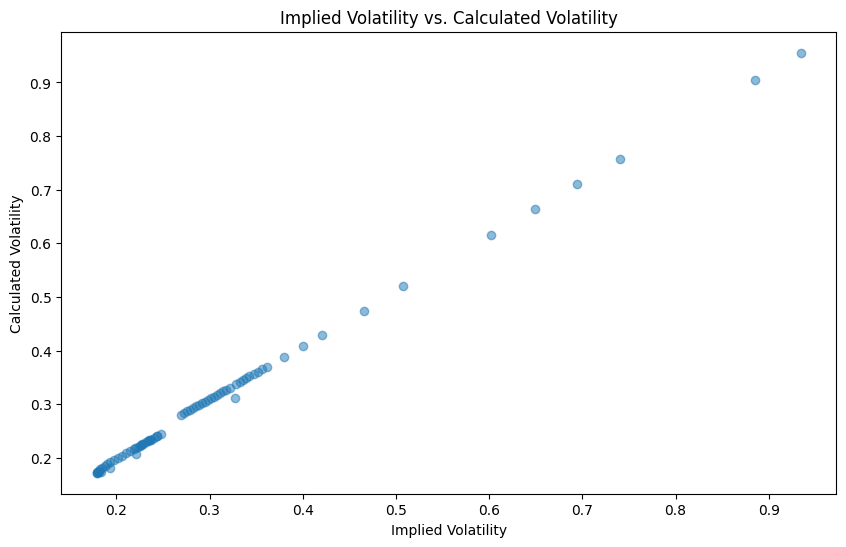

In [97]:
plt.figure(figsize=(10, 6))
plt.scatter(comparison_target['impliedVolatility'], comparison_target['calculated_iv'], alpha=0.5)
plt.xlabel('Implied Volatility')
plt.ylabel('Calculated Volatility')
plt.title('Implied Volatility vs. Calculated Volatility')
plt.show()

In [98]:
comparison_target[
    (comparison_target["impliedVolatility"] < 0.08) &
    (comparison_target["calculated_iv"] < 0.06)
][[
    "type", "strike", "mid",
    "impliedVolatility", "calculated_iv","Spot"
]].sort_values("strike")


,type,strike,mid,impliedVolatility,calculated_iv,Spot


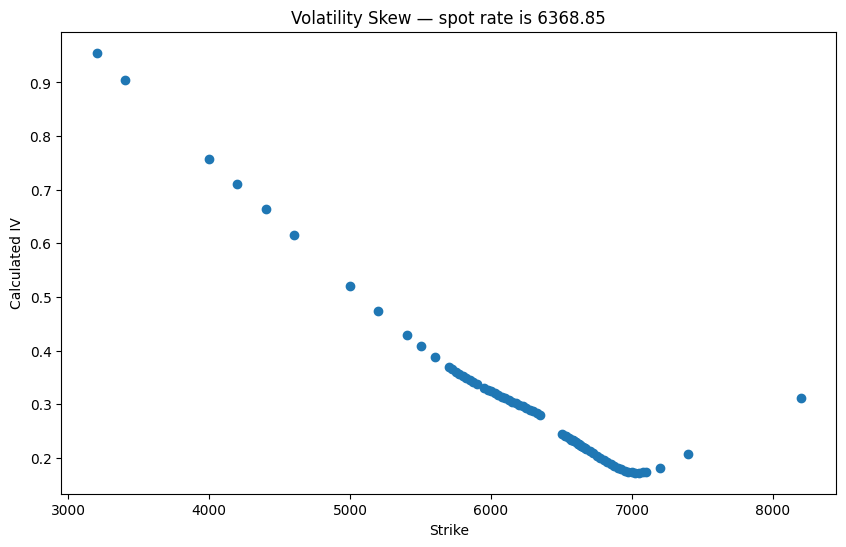

In [99]:

plt.figure(figsize=(10, 6))
plt.scatter(comparison_target['strike'],comparison_target['calculated_iv'])
plt.xlabel('Strike')
plt.ylabel('Calculated IV')
plt.title(f"Volatility Skew — spot rate is {comparison_target['Spot'].iloc[0]:.2f}")
plt.show()

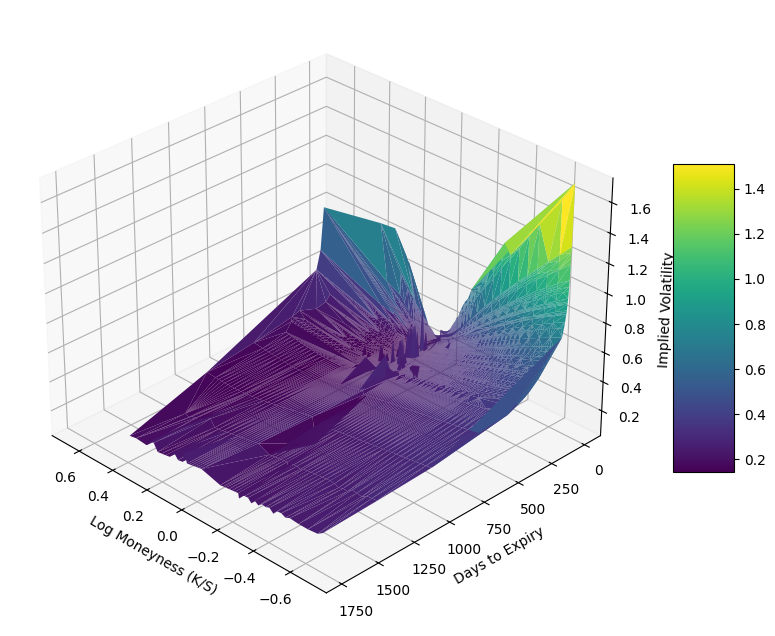

In [100]:
plot_vol_surface(comparison_df)

#SVI

In [103]:
comparison_df['total_var'] = (comparison_df['calculated_iv']**2)*comparison_df['T']
comparison_target['total_var'] = (comparison_target['calculated_iv']**2)*comparison_target['T']
k_data=comparison_target['log_moneyness'].values
w_data=comparison_target['total_var'].values
T_target=comparison_target['T'].iloc[0]

In [104]:
initial_guess=[0.01,0.2,-0.3,0.0,0.1]
lower_bounds=[-1.0,1e-6,-0.999,-2.0,1e-6]
upper_bounds=[ 1.0,10.0, 0.999, 2.0,2.0]

svi_fit=least_squares(svi_residuals,initial_guess,args=(k_data,w_data),bounds=(lower_bounds,upper_bounds))

In [105]:
a_fit,b_fit,rho_fit,m_fit,sigma_fit=svi_fit.x
print("SVI params:")
print("a     =",a_fit)
print("b     =",b_fit)
print("rho   =",rho_fit)
print("m     =",m_fit)
print("sigma =",sigma_fit)

SVI params:
a     = -0.21101140306135152
b     = 1.2652553577289376
rho   = 0.8828065906158458
m     = 0.7900141374162255
sigma = 0.3590268977633743


In [106]:
comparison_target=comparison_df[comparison_df['expiry']==pd.to_datetime(expiry_selected)].copy()
comparison_target,svi_params=fit_svi_by_expiry(comparison_target)

print(
    f"""
SVI parameters for expiry {expiry_selected}
a     = {svi_params[0]:.6f}
b     = {svi_params[1]:.6f}
rho   = {svi_params[2]:.6f}
m     = {svi_params[3]:.6f}
sigma = {svi_params[4]:.6f}
"""
)


SVI parameters for expiry 2026-04-22
a     = -0.211011
b     = 1.265255
rho   = 0.882807
m     = 0.790014
sigma = 0.359027



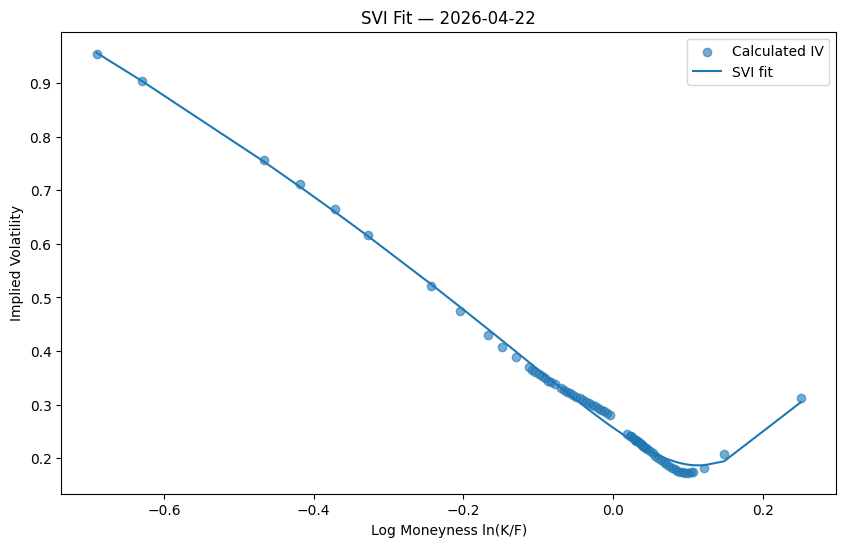

In [107]:
comparison_target_sorted=comparison_target.sort_values('log_moneyness')

plt.figure(figsize=(10,6))
plt.scatter(comparison_target['log_moneyness'],comparison_target['calculated_iv'],label='Calculated IV',alpha=0.6)
plt.plot(comparison_target_sorted['log_moneyness'],comparison_target_sorted['svi_iv'],label='SVI fit')
plt.xlabel('Log Moneyness ln(K/F)')
plt.ylabel('Implied Volatility')
plt.title(f'SVI Fit — {expiry_selected}')
plt.legend()
plt.show()

In [108]:
svi_slices=[]
svi_params_list=[]

for expiry,df_slice in comparison_df.groupby('expiry'):
  df_slice=df_slice.copy()
  df_slice,svi_params=fit_svi_by_expiry(df_slice)

  svi_slices.append(df_slice)

  svi_params_list.append({
      'expiry':expiry,
      'T':df_slice['T'].iloc[0],
      'a':svi_params[0],
      'b':svi_params[1],
      'rho':svi_params[2],
      'm':svi_params[3],
      'sigma':svi_params[4]
  })

In [109]:
comparison_svi_df=pd.concat(svi_slices,ignore_index=True)
svi_params_df=pd.DataFrame(svi_params_list).sort_values('T')

In [110]:
print(svi_params_df.head())

      expiry         T         a         b       rho         m     sigma
0 2026-03-30  0.005479 -0.048842  0.084657  0.082213  0.067730  0.583745
1 2026-03-31  0.008219 -0.156848  0.367721  0.731319  0.698799  0.627894
2 2026-04-01  0.010959 -0.164588  0.394021  0.738505  0.720426  0.622504
3 2026-04-02  0.013699 -0.418615  0.431371  0.584289  0.908418  1.198576
4 2026-04-06  0.024658 -0.224392  0.558792  0.766042  0.811583  0.628137


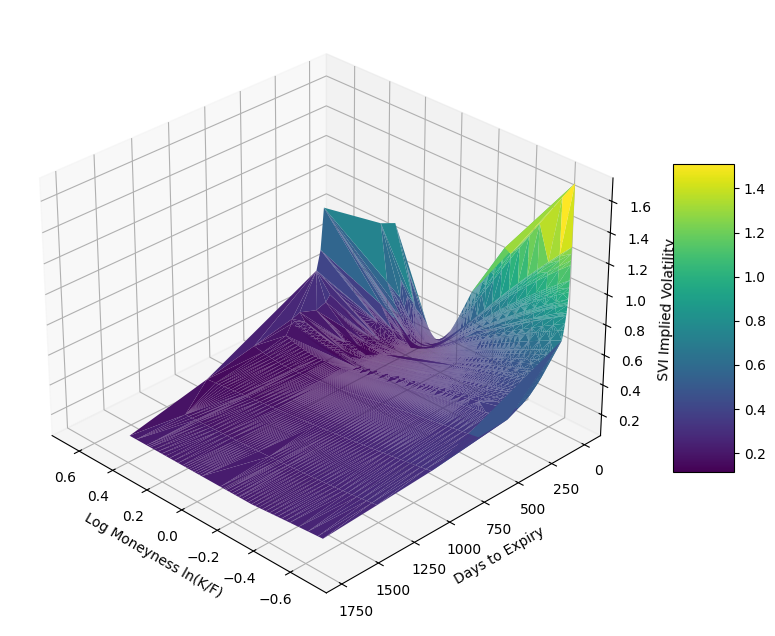

In [111]:
plot_svi_surface(comparison_svi_df)

#Comparison between SVI Black and Scholes and Yahoo IV

In [112]:
target_compare=comparison_svi_df[
    comparison_svi_df['expiry']==pd.to_datetime(expiry_selected)
].copy()

target_compare=target_compare.sort_values('log_moneyness')

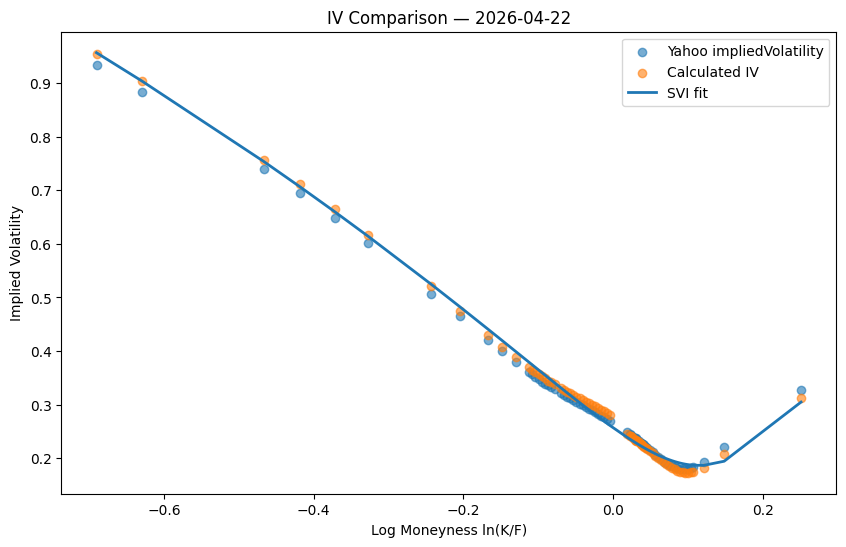

In [113]:
plt.figure(figsize=(10,6))

plt.scatter(
    target_compare['log_moneyness'],
    target_compare['impliedVolatility'],
    label='Yahoo impliedVolatility',
    alpha=0.6
)

plt.scatter(
    target_compare['log_moneyness'],
    target_compare['calculated_iv'],
    label='Calculated IV',
    alpha=0.6
)

plt.plot(
    target_compare['log_moneyness'],
    target_compare['svi_iv'],
    label='SVI fit',
    linewidth=2
)

plt.xlabel('Log Moneyness ln(K/F)')
plt.ylabel('Implied Volatility')
plt.title(f'IV Comparison — {expiry_selected}')
plt.legend()
plt.show()

In [114]:
comparison_svi_df['iv_residual']=comparison_svi_df['calculated_iv']-comparison_svi_df['svi_iv']

In [115]:
target_trade=comparison_svi_df[
    comparison_svi_df['expiry']==pd.to_datetime(expiry_selected)
].copy()

target_trade[['type','strike','log_moneyness','calculated_iv','svi_iv','iv_residual']].sort_values('iv_residual')

,type,strike,log_moneyness,calculated_iv,svi_iv,iv_residual
2834,call,7000.0,0.092806,0.173413,0.189567,-0.016154
2833,call,6975.0,0.089228,0.174823,0.190734,-0.015911
2832,call,6950.0,0.085638,0.176353,0.192062,-0.015709
2835,call,7025.0,0.096371,0.172911,0.188563,-0.015652
2836,call,7050.0,0.099924,0.172578,0.187726,-0.015148
...,...,...,...,...,...,...
2874,put,6250.0,-0.020522,0.293298,0.277619,0.015679
2875,put,6275.0,-0.016530,0.290246,0.273451,0.016795
2876,put,6300.0,-0.012554,0.287100,0.269338,0.017761
2877,put,6325.0,-0.008594,0.283987,0.265282,0.018705
